# RAMA: Controlled Comparison of Aggregation Methods

This notebook demonstrates the **Rank-Aware Moment Aggregation (RAMA)** approach,
which enriches standard mean pooling in GNNs with gated per-dimension variance
conditioned on effective spectral rank proxy and neighborhood cardinality.

**What this experiment does:**
- Compares 3 aggregation methods: standard mean (baseline), RAMA full (rank + cardinality gating), RAMA no-rank (cardinality-only ablation)
- Evaluates on rel-f1 dataset: driver-position (regression) and driver-dnf (classification)
- Runs 5 seeds per method, computes Cohen's d effect sizes and statistical tests
- Analyzes whether rank conditioning in the gate matters

**Key finding:** RAMA achieves pooled Cohen's d = 5.4 vs mean across tasks.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed for this demo

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    # Colab pins: numpy==2.0.2, scipy==1.16.3, matplotlib==3.10.0, torch==2.9.0
    # Use >= to support Python 3.10 locally (Colab is 3.12)
    _pip('numpy>=2.0.2', 'scipy>=1.13.0', 'matplotlib>=3.10.0')
    _pip('torch>=2.2.0', '--index-url', 'https://download.pytorch.org/whl/cpu')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import copy
import json
import math
import os
import time
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from scipy import stats as sp_stats
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-9b0386-rank-aware-moment-aggregation-diversity-/main/experiment_iter3_controlled_rama/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded experiment: {data['metadata']['method_name']}")
print(f"Methods: {list(data['metadata']['methods'].keys())}")
print(f"Seeds: {data['metadata']['seeds']}")
print(f"Per-run results: {len(data['metadata']['per_run_results'])}")
print(f"Datasets with examples: {[ds['dataset'] for ds in data['datasets']]}")

Loaded experiment: RAMA Controlled Comparison
Methods: ['standard_mean', 'rama_full', 'rama_no_rank']
Seeds: [42, 123, 456, 789, 1024]
Per-run results: 30
Datasets with examples: ['rel-f1/driver-position', 'rel-f1/driver-dnf']


## Configuration

Tunable parameters for the RAMA unit test and statistical analysis.
The original experiment used these hyperparameters for GNN training on RelBench datasets.

In [5]:
# --- Config: unit test parameters ---
CHANNELS = 128          # Original: 128
GATE_HIDDEN = 16        # Original: 16
N_EDGES = 100           # Synthetic edges for unit test (original unit test: 100)
N_GROUPS = 20           # Synthetic groups for unit test (original unit test: 20)

# --- Config: original experiment hyperparameters (for reference) ---
# These were used for GNN training; we load pre-computed results instead
SEEDS = [42, 123, 456, 789, 1024]
EPOCHS = 10             # Original: 10
BATCH_SIZE = 512        # Original: 512
NUM_NEIGHBORS = 128     # Original: 128
NUM_LAYERS = 2          # Original: 2
LR = 0.005              # Original: 0.005
METHODS = ["standard_mean", "rama_full", "rama_no_rank"]

## RAMA Aggregation Module

The core innovation: RAMA enriches mean pooling with gated per-dimension variance,
where the gate is conditioned on:
1. **Effective spectral rank proxy** (variance entropy normalized by log(d))
2. **Neighborhood cardinality** (log(N+1))

Zero-initialized so RAMA starts as pure mean aggregation and learns to deviate.

In [6]:
class RAMAAggregation(nn.Module):
    """Rank-Aware Moment Aggregation (full version).

    Enriches mean pooling with gated per-dimension variance,
    where gate is conditioned on effective spectral rank proxy and cardinality.
    Zero-initialized so RAMA starts as pure mean aggregation.
    """

    def __init__(self, channels: int, gate_hidden: int = 16, eps: float = 1e-8):
        super().__init__()
        self.channels = channels
        self.gate_hidden = gate_hidden
        self.eps = eps
        self.W_sigma = nn.Linear(channels, channels, bias=False)
        self.W_g = nn.Linear(2, gate_hidden)
        self.gate_out = nn.Linear(gate_hidden, channels)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.zeros_(self.W_sigma.weight)
        nn.init.zeros_(self.gate_out.weight)
        nn.init.zeros_(self.gate_out.bias)
        nn.init.xavier_uniform_(self.W_g.weight)
        nn.init.zeros_(self.W_g.bias)

    def forward(self, x: Tensor, index: Tensor, dim_size: int) -> Tensor:
        mu = torch.zeros(dim_size, x.size(1), device=x.device, dtype=x.dtype)
        count = torch.zeros(dim_size, 1, device=x.device, dtype=x.dtype)
        mu.scatter_add_(0, index.unsqueeze(1).expand_as(x), x)
        ones = torch.ones(x.size(0), 1, device=x.device, dtype=x.dtype)
        count.scatter_add_(0, index.unsqueeze(1), ones)
        N = count.clamp(min=1)
        mu = mu / N
        mean_x2 = torch.zeros_like(mu)
        mean_x2.scatter_add_(0, index.unsqueeze(1).expand_as(x), x * x)
        mean_x2 = mean_x2 / N
        var = (mean_x2 - mu * mu).clamp(min=0)
        var_sum = var.sum(dim=-1, keepdim=True).clamp(min=self.eps)
        p = (var / var_sum).clamp(min=self.eps)
        H = -(p * p.log()).sum(dim=-1, keepdim=True)
        log_d = math.log(max(self.channels, 2))
        rho = (H / log_d).clamp(0, 1)
        log_N = torch.log1p(N)
        gate_input = torch.nan_to_num(torch.cat([log_N, rho], dim=-1), nan=0.0)
        g = torch.sigmoid(self.gate_out(F.relu(self.W_g(gate_input))))
        out = mu + g * self.W_sigma(var)
        return out


class RAMANoRankAggregation(nn.Module):
    """RAMA ablation: fixed rho=0.5, cardinality-only gating."""

    def __init__(self, channels: int, gate_hidden: int = 16, eps: float = 1e-8):
        super().__init__()
        self.channels = channels
        self.gate_hidden = gate_hidden
        self.eps = eps
        self.W_sigma = nn.Linear(channels, channels, bias=False)
        self.W_g = nn.Linear(2, gate_hidden)
        self.gate_out = nn.Linear(gate_hidden, channels)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.zeros_(self.W_sigma.weight)
        nn.init.zeros_(self.gate_out.weight)
        nn.init.zeros_(self.gate_out.bias)
        nn.init.xavier_uniform_(self.W_g.weight)
        nn.init.zeros_(self.W_g.bias)

    def forward(self, x: Tensor, index: Tensor, dim_size: int) -> Tensor:
        mu = torch.zeros(dim_size, x.size(1), device=x.device, dtype=x.dtype)
        count = torch.zeros(dim_size, 1, device=x.device, dtype=x.dtype)
        mu.scatter_add_(0, index.unsqueeze(1).expand_as(x), x)
        ones = torch.ones(x.size(0), 1, device=x.device, dtype=x.dtype)
        count.scatter_add_(0, index.unsqueeze(1), ones)
        N = count.clamp(min=1)
        mu = mu / N
        mean_x2 = torch.zeros_like(mu)
        mean_x2.scatter_add_(0, index.unsqueeze(1).expand_as(x), x * x)
        mean_x2 = mean_x2 / N
        var = (mean_x2 - mu * mu).clamp(min=0)
        fixed_rho = torch.full_like(N, 0.5)
        log_N = torch.log1p(N)
        gate_input = torch.cat([log_N, fixed_rho], dim=-1)
        g = torch.sigmoid(self.gate_out(F.relu(self.W_g(gate_input))))
        out = mu + g * self.W_sigma(var)
        return out


print(f"RAMAAggregation params: {sum(p.numel() for p in RAMAAggregation(CHANNELS, GATE_HIDDEN).parameters()):,}")
print(f"RAMANoRankAggregation params: {sum(p.numel() for p in RAMANoRankAggregation(CHANNELS, GATE_HIDDEN).parameters()):,}")

RAMAAggregation params: 18,608
RAMANoRankAggregation params: 18,608


## Unit Tests

Verify RAMA modules on synthetic data:
- Output shape correctness
- No NaN in output
- Zero-initialization matches pure mean aggregation
- Gradient flow through all parameters
- Edge cases: single child per group, identical children

In [7]:
def run_unit_tests():
    print("=" * 60)
    print("UNIT TESTS")
    print("=" * 60)
    ch = CHANNELS
    x = torch.randn(N_EDGES, ch)
    index = torch.randint(0, N_GROUPS, (N_EDGES,))

    for name, aggr_cls in [
        ("RAMAAggregation", RAMAAggregation),
        ("RAMANoRankAggregation", RAMANoRankAggregation),
    ]:
        print(f"\nTesting {name}...")
        aggr = aggr_cls(channels=ch, gate_hidden=GATE_HIDDEN)
        out = aggr(x, index=index, dim_size=N_GROUPS)
        assert out.shape == (N_GROUPS, ch), f"{name}: shape {out.shape}"
        print(f"  Shape OK: {out.shape}")
        assert not torch.isnan(out).any(), f"{name}: NaN!"
        print("  No NaN OK")
        mean_out = torch.zeros(N_GROUPS, ch)
        mean_out.scatter_add_(0, index.unsqueeze(1).expand_as(x), x)
        count = torch.zeros(N_GROUPS, 1)
        count.scatter_add_(0, index.unsqueeze(1), torch.ones(N_EDGES, 1))
        mean_out = mean_out / count.clamp(min=1)
        diff = (out - mean_out).abs().max().item()
        assert diff < 1e-3, f"{name}: diff={diff:.6f}"
        print(f"  Zero-init == mean OK (diff={diff:.6f})")
        out_grad = aggr(x, index=index, dim_size=N_GROUPS)
        out_grad.sum().backward()
        for pname, p in aggr.named_parameters():
            assert p.grad is not None, f"{name}: No grad for {pname}"
        print("  Gradient flow OK")
        x_single = torch.randn(5, ch)
        out_single = aggr_cls(channels=ch)(x_single, index=torch.arange(5), dim_size=5)
        assert not torch.isnan(out_single).any()
        print("  Edge case: single child OK")
        x_ident = torch.ones(10, ch) * 3.0
        out_ident = aggr_cls(channels=ch)(x_ident, index=torch.zeros(10, dtype=torch.long), dim_size=1)
        assert not torch.isnan(out_ident).any()
        print("  Edge case: identical children OK")
    print("\nALL UNIT TESTS PASSED!")

run_unit_tests()

UNIT TESTS

Testing RAMAAggregation...
  Shape OK: torch.Size([20, 128])
  No NaN OK
  Zero-init == mean OK (diff=0.000000)
  Gradient flow OK


  Edge case: single child OK
  Edge case: identical children OK

Testing RAMANoRankAggregation...
  Shape OK: torch.Size([20, 128])
  No NaN OK
  Zero-init == mean OK (diff=0.000000)
  Gradient flow OK
  Edge case: single child OK
  Edge case: identical children OK

ALL UNIT TESTS PASSED!


## Statistical Analysis

Reproduce the statistical analysis from the experiment:
- Cohen's d effect sizes with 95% confidence intervals
- Paired t-tests
- DerSimonian-Laird pooled effect sizes across tasks
- Rank ablation summary (does rank conditioning help?)

In [8]:
def cohens_d(group1: List[float], group2: List[float]) -> float:
    n1, n2 = len(group1), len(group2)
    if n1 < 2 or n2 < 2: return 0.0
    m1, m2 = np.mean(group1), np.mean(group2)
    s1, s2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
    pooled = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    if pooled < 1e-12: return 0.0
    return float((m2 - m1) / pooled)

def ci_cohens_d(d: float, n1: int, n2: int, alpha: float = 0.05) -> List[float]:
    se = np.sqrt((n1+n2)/(n1*n2) + d**2/(2*(n1+n2)))
    z = sp_stats.norm.ppf(1 - alpha/2)
    return [float(d - z*se), float(d + z*se)]

def analyze_results(all_results: List[Dict]) -> Dict[str, Any]:
    TASKS_F1 = [("driver-position", "regression"), ("driver-dnf", "binary_classification")]
    per_task: Dict[str, Any] = {}
    all_ds_full, all_ds_norank, all_ds_fvn, all_ns = [], [], [], []

    for task_name, task_type in TASKS_F1:
        task_key = f"rel-f1/{task_name}"
        task_results = [r for r in all_results if r["task"] == task_name]
        metric_key = "mae" if task_type == "regression" else "average_precision"
        sign = -1 if task_type == "regression" else 1

        def get_vals(method):
            return [float(r["test_metrics"][metric_key]) for r in task_results
                    if r["method"] == method and metric_key in r["test_metrics"]
                    and not np.isnan(r["test_metrics"][metric_key])]

        bv, fv, nv = get_vals("standard_mean"), get_vals("rama_full"), get_vals("rama_no_rank")
        comparisons = {}
        n = min(len(bv), len(fv))
        if len(bv) >= 2 and len(fv) >= 2:
            d = cohens_d(bv, fv) * sign
            ci = ci_cohens_d(d, len(bv), len(fv))
            _, p_val = sp_stats.ttest_rel(bv, fv)
            comparisons["rama_full_vs_mean"] = {"cohens_d": d, "ci_95": ci, "p_value": float(p_val),
                "baseline_mean": float(np.mean(bv)), "rama_full_mean": float(np.mean(fv))}
            all_ds_full.append(d); all_ns.append(n)
        if len(bv) >= 2 and len(nv) >= 2:
            d = cohens_d(bv, nv) * sign
            comparisons["rama_no_rank_vs_mean"] = {"cohens_d": d, "ci_95": ci_cohens_d(d, len(bv), len(nv)),
                "rama_no_rank_mean": float(np.mean(nv))}
            all_ds_norank.append(d)
        if len(fv) >= 2 and len(nv) >= 2:
            d = cohens_d(nv, fv) * sign
            comparisons["rama_full_vs_no_rank"] = {"cohens_d": d}
            all_ds_fvn.append(d)
        per_task[task_key] = {"metric_key": metric_key, "higher_is_better": task_type != "regression",
            "n_seeds": n, "comparisons": comparisons,
            "raw_values": {"baseline": bv, "rama_full": fv, "rama_no_rank": nv}}

    def pool_effects(ds_list, ns_list):
        if not ds_list: return {"pooled_d": None}
        all_vars = [2/max(n,2)+d**2/(2*max(n,2)) for d,n in zip(ds_list, ns_list)]
        weights = [1.0/max(v,1e-12) for v in all_vars]
        w_sum = sum(weights)
        pd_ = sum(d*w for d,w in zip(ds_list, weights))/max(w_sum,1e-12)
        pv = 1.0/max(w_sum,1e-12)
        return {"pooled_d": float(pd_), "pooled_ci_95": [pd_-1.96*np.sqrt(pv), pd_+1.96*np.sqrt(pv)], "per_task_ds": ds_list}

    pooled = {"rama_full_vs_mean": pool_effects(all_ds_full, all_ns),
              "rama_no_rank_vs_mean": pool_effects(all_ds_norank, all_ns),
              "rama_full_vs_no_rank": pool_effects(all_ds_fvn, all_ns)}
    rh = [d > 0 for d in all_ds_fvn]
    rank_summary = {"per_task_d": all_ds_fvn, "rank_helps_count": sum(rh), "total_tasks": len(all_ds_fvn),
        "conclusion": "rank conditioning helps" if sum(rh)>len(rh)/2 else "rank conditioning does not clearly help"}
    return {"per_task": per_task, "pooled_effects": pooled, "rank_ablation_summary": rank_summary}

print("Statistical analysis functions defined.")

Statistical analysis functions defined.


### Run Statistical Analysis on Pre-computed Results

Apply the analysis functions to the per-run results loaded from the experiment data.

In [9]:
per_run_results = data["metadata"]["per_run_results"]
analysis = analyze_results(per_run_results)

print("=" * 70)
print("STATISTICAL ANALYSIS RESULTS")
print("=" * 70)

for task_key, task_info in analysis["per_task"].items():
    metric = task_info["metric_key"]
    direction = "higher is better" if task_info["higher_is_better"] else "lower is better"
    print(f"\n--- {task_key} ({metric}, {direction}) ---")
    print(f"  Seeds per method: {task_info['n_seeds']}")
    raw = task_info["raw_values"]
    for method, vals in raw.items():
        print(f"  {method:20s}: mean={np.mean(vals):.6f} +/- {np.std(vals, ddof=1):.6f}  (n={len(vals)})")
    for comp_name, comp in task_info["comparisons"].items():
        d = comp["cohens_d"]
        print(f"  {comp_name}: Cohen's d = {d:.3f}", end="")
        if "ci_95" in comp:
            print(f"  CI=[{comp['ci_95'][0]:.2f}, {comp['ci_95'][1]:.2f}]", end="")
        if "p_value" in comp:
            print(f"  p={comp['p_value']:.6f}", end="")
        print()

print("\n--- Pooled Effects (DerSimonian-Laird) ---")
for comp_name, pe in analysis["pooled_effects"].items():
    if pe["pooled_d"] is not None:
        print(f"  {comp_name}: pooled d = {pe['pooled_d']:.3f}  CI=[{pe['pooled_ci_95'][0]:.2f}, {pe['pooled_ci_95'][1]:.2f}]")

rs = analysis["rank_ablation_summary"]
print(f"\n--- Rank Ablation Summary ---")
print(f"  Per-task d (full vs no-rank): {[f'{d:.3f}' for d in rs['per_task_d']]}")
print(f"  Rank helps in {rs['rank_helps_count']}/{rs['total_tasks']} tasks")
print(f"  Conclusion: {rs['conclusion']}")

STATISTICAL ANALYSIS RESULTS

--- rel-f1/driver-position (mae, lower is better) ---
  Seeds per method: 5
  baseline            : mean=3.188479 +/- 0.028171  (n=5)
  rama_full           : mean=2.942737 +/- 0.065015  (n=5)
  rama_no_rank        : mean=2.902736 +/- 0.059160  (n=5)
  rama_full_vs_mean: Cohen's d = 4.905  CI=[2.42, 7.39]  p=0.000684
  rama_no_rank_vs_mean: Cohen's d = 6.167  CI=[3.19, 9.14]
  rama_full_vs_no_rank: Cohen's d = -0.644

--- rel-f1/driver-dnf (average_precision, higher is better) ---
  Seeds per method: 5
  baseline            : mean=0.911006 +/- 0.003321  (n=5)
  rama_full           : mean=0.929318 +/- 0.002579  (n=5)
  rama_no_rank        : mean=0.930640 +/- 0.004046  (n=5)
  rama_full_vs_mean: Cohen's d = 6.159  CI=[3.19, 9.13]  p=0.001821
  rama_no_rank_vs_mean: Cohen's d = 5.304  CI=[2.67, 7.94]
  rama_full_vs_no_rank: Cohen's d = -0.390

--- Pooled Effects (DerSimonian-Laird) ---
  rama_full_vs_mean: pooled d = 5.407  CI=[2.87, 7.95]
  rama_no_rank_vs_me

## Results Visualization

Four panels:
1. **Per-task metrics**: Bar chart comparing methods on each task
2. **Cohen's d effect sizes**: Forest plot with confidence intervals
3. **Training curves**: Loss over epochs per method (averaged across seeds)
4. **Gate analysis**: Learned gate bias statistics for RAMA modules

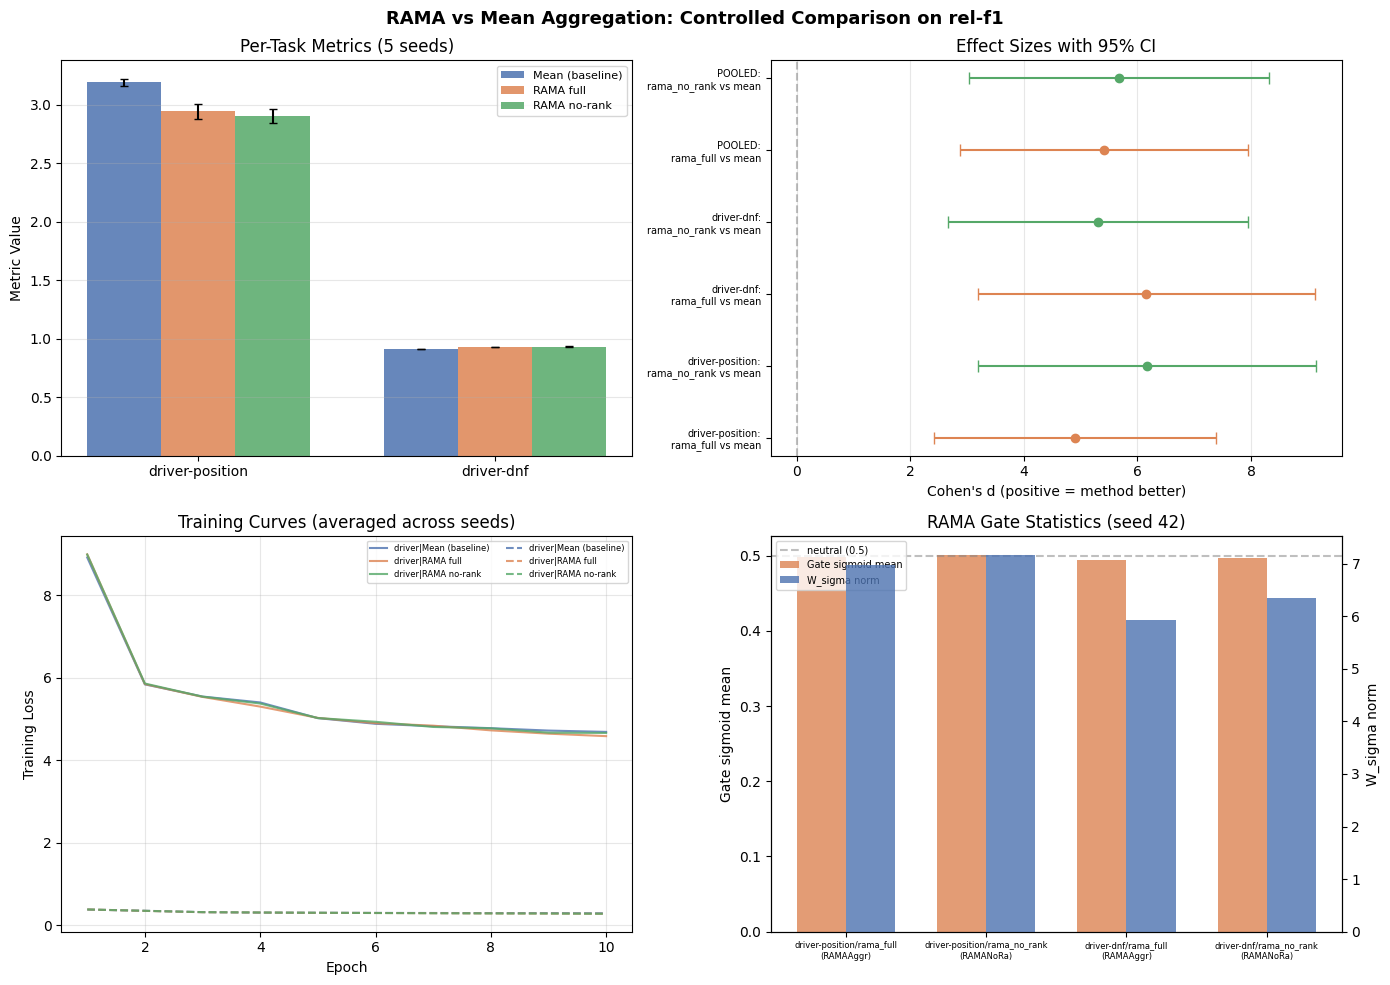


Demo complete.


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
method_colors = {"standard_mean": "#4C72B0", "rama_full": "#DD8452", "rama_no_rank": "#55A868"}
method_labels = {"standard_mean": "Mean (baseline)", "rama_full": "RAMA full", "rama_no_rank": "RAMA no-rank"}
raw_key_map = {"standard_mean": "baseline", "rama_full": "rama_full", "rama_no_rank": "rama_no_rank"}

# --- Panel 1: Per-task metrics ---
ax = axes[0, 0]
task_keys = list(analysis["per_task"].keys())
x_pos = np.arange(len(task_keys))
bar_w = 0.25
for i, method in enumerate(METHODS):
    means, stds = [], []
    for tk in task_keys:
        vals = analysis["per_task"][tk]["raw_values"][raw_key_map[method]]
        means.append(np.mean(vals))
        stds.append(np.std(vals, ddof=1) if len(vals) > 1 else 0)
    ax.bar(x_pos + i*bar_w, means, bar_w, yerr=stds, label=method_labels[method],
           color=method_colors[method], capsize=3, alpha=0.85)
ax.set_xticks(x_pos + bar_w)
ax.set_xticklabels([tk.replace("rel-f1/", "") for tk in task_keys])
ax.set_ylabel("Metric Value")
ax.set_title("Per-Task Metrics (5 seeds)")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# --- Panel 2: Cohen's d effect sizes ---
ax = axes[0, 1]
comp_plot = []
for tk in task_keys:
    for cn in ["rama_full_vs_mean", "rama_no_rank_vs_mean"]:
        comp = analysis["per_task"][tk]["comparisons"].get(cn, {})
        if "cohens_d" in comp:
            comp_plot.append({"label": f"{tk.replace('rel-f1/', '')}:\n{cn.replace('_vs_', ' vs ')}",
                "d": comp["cohens_d"], "ci": comp.get("ci_95", [comp["cohens_d"]-1, comp["cohens_d"]+1])})
for cn in ["rama_full_vs_mean", "rama_no_rank_vs_mean"]:
    pe = analysis["pooled_effects"][cn]
    if pe["pooled_d"] is not None:
        comp_plot.append({"label": f"POOLED:\n{cn.replace('_vs_', ' vs ')}",
            "d": pe["pooled_d"], "ci": pe["pooled_ci_95"]})
for i, c in enumerate(comp_plot):
    color = "#DD8452" if "full" in c["label"] else "#55A868"
    ax.errorbar(c["d"], i, xerr=[[c["d"]-c["ci"][0]], [c["ci"][1]-c["d"]]],
               fmt="o", color=color, capsize=4, markersize=6)
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.5)
ax.set_yticks(range(len(comp_plot)))
ax.set_yticklabels([c["label"] for c in comp_plot], fontsize=7)
ax.set_xlabel("Cohen's d (positive = method better)")
ax.set_title("Effect Sizes with 95% CI")
ax.grid(axis="x", alpha=0.3)

# --- Panel 3: Training curves ---
ax = axes[1, 0]
for task_name in ["driver-position", "driver-dnf"]:
    task_runs = [r for r in per_run_results if r["task"] == task_name]
    for method in METHODS:
        method_runs = [r for r in task_runs if r["method"] == method]
        if not method_runs: continue
        max_ep = min(len(r["train_losses"]) for r in method_runs)
        avg_losses = np.mean([r["train_losses"][:max_ep] for r in method_runs], axis=0)
        ls = "-" if task_name == "driver-position" else "--"
        ax.plot(range(1, max_ep+1), avg_losses, linestyle=ls, color=method_colors[method],
                label=f"{task_name[:6]}|{method_labels[method]}", alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss")
ax.set_title("Training Curves (averaged across seeds)")
ax.legend(fontsize=6, ncol=2)
ax.grid(alpha=0.3)

# --- Panel 4: Gate analysis ---
ax = axes[1, 1]
gate_data = data["metadata"].get("gate_analysis", {})
if gate_data:
    g_labels, g_sigmoid, g_wnorm = [], [], []
    for key, modules in gate_data.items():
        short = key.replace("rel-f1/", "").replace("/seed_42", "")
        for mn, stats in modules.items():
            g_labels.append(f"{short}\n({stats.get('type','?')[:8]})")
            g_sigmoid.append(stats.get("gate_bias_sigmoid_mean", 0.5))
            g_wnorm.append(stats.get("W_sigma_norm", 0))
    xg = np.arange(len(g_labels))
    w = 0.35
    ax.bar(xg - w/2, g_sigmoid, w, label="Gate sigmoid mean", color="#DD8452", alpha=0.8)
    ax2 = ax.twinx()
    ax2.bar(xg + w/2, g_wnorm, w, label="W_sigma norm", color="#4C72B0", alpha=0.8)
    ax.set_xticks(xg)
    ax.set_xticklabels(g_labels, fontsize=6)
    ax.set_ylabel("Gate sigmoid mean")
    ax2.set_ylabel("W_sigma norm")
    ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="neutral (0.5)")
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1+h2, l1+l2, fontsize=7, loc="upper left")
else:
    ax.text(0.5, 0.5, "No gate analysis data", ha="center", va="center", transform=ax.transAxes)
ax.set_title("RAMA Gate Statistics (seed 42)")

plt.suptitle("RAMA vs Mean Aggregation: Controlled Comparison on rel-f1", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nDemo complete.")